In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load train/test splits saved by the data cleaning pipeline
train_df = pd.read_csv("tfidf_train.csv")
test_df  = pd.read_csv("tfidf_test.csv")

# Ensure label columns are plain strings
train_df["review_type"] = train_df["review_type"].astype(str).str.strip()
test_df["review_type"]  = test_df["review_type"].astype(str).str.strip()

y_train = train_df["review_type"]
y_test  = test_df["review_type"]

# Re-fit TF-IDF on the training set
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["final_cleaned"])
X_test  = vectorizer.transform(test_df["final_cleaned"])

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())

X_train shape: (546825, 5000)
X_test shape: (136707, 5000)
y_train distribution:
review_type
Rotten    273413
Fresh     273412
Name: count, dtype: int64

y_test distribution:
review_type
Fresh     68354
Rotten    68353
Name: count, dtype: int64


# Train Logistic Regression Model

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
lr_model = LogisticRegression(
    max_iter=1000,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

# Train model
lr_model.fit(X_train, y_train)

print("Model training completed.")

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model training completed.


### Evaluate the model

In [3]:
# Predict test data
y_pred = lr_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.7720453232094918

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.7723    0.7716    0.7719     68354
      Rotten     0.7718    0.7725    0.7721     68353

    accuracy                         0.7720    136707
   macro avg     0.7720    0.7720    0.7720    136707
weighted avg     0.7720    0.7720    0.7720    136707


Confusion Matrix:
[[52743 15611]
 [15552 52801]]


### Plot confusion matrix

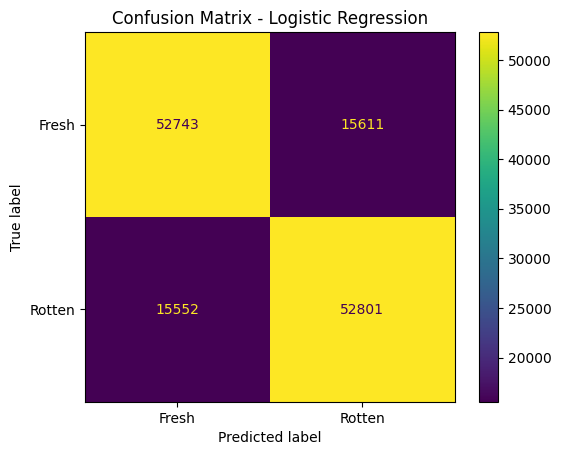

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Test with new review

In [5]:
def predict_review_sentiment(review_text):
    review_tfidf = vectorizer.transform([review_text])
    prediction = lr_model.predict(review_tfidf)[0]
    return prediction

sample_review = "The movie was emotional, well acted, and beautifully directed."
print("Prediction:", predict_review_sentiment(sample_review))

sample_review_2 = "The movie was boring, badly written, and too long."
print("Prediction:", predict_review_sentiment(sample_review_2))

Prediction: Fresh
Prediction: Rotten


# Train SVM Model

In [6]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred, digits=4))

SVM Accuracy: 0.7717307818911979

SVM Classification Report:
              precision    recall  f1-score   support

       Fresh     0.7718    0.7717    0.7717     68354
      Rotten     0.7717    0.7718    0.7717     68353

    accuracy                         0.7717    136707
   macro avg     0.7717    0.7717    0.7717    136707
weighted avg     0.7717    0.7717    0.7717    136707



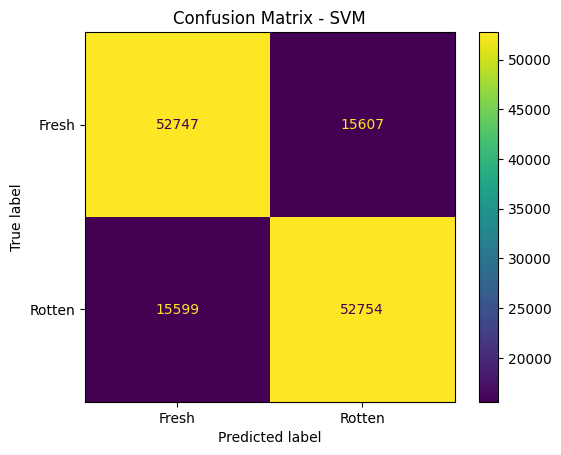

In [7]:
cm_svm = confusion_matrix(y_test, svm_pred)

disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp1.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

# Comparison LR vs SVM

In [8]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro Recall": recall_score(y_true, y_pred, average="macro"),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted")
    }

results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred))
results.append(evaluate_model("Linear SVM", y_test, svm_pred))

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.772045,0.772046,0.772045,0.772045,0.772045
1,Linear SVM,0.771731,0.771731,0.771731,0.771731,0.771731


### Generative Opinion Summarization

In [9]:
import ollama

# Sample reviews from the train CSV using the review_content column
fresh_reviews  = train_df.loc[y_train == "Fresh",  "review_content"].sample(30, random_state=42).tolist()
rotten_reviews = train_df.loc[y_train == "Rotten", "review_content"].sample(30, random_state=42).tolist()

def summarize_reviews(reviews, sentiment_label):
    reviews_text = "\n".join([f"- {r}" for r in reviews])

    prompt = f"""
    Here are 30 {sentiment_label} movie reviews:
    {reviews_text}

    Write a structured executive summary covering:
    1. Overall sentiment
    2. Most praised aspects
    3. Most criticised aspects
    4. Common themes
    """

    response = ollama.chat(model='llama3', messages=[
        {"role": "user", "content": prompt}
    ])

    return response['message']['content']

fresh_summary  = summarize_reviews(fresh_reviews,  "Fresh (positive)")
rotten_summary = summarize_reviews(rotten_reviews, "Rotten (negative)")

print("=== FRESH REVIEWS SUMMARY ===")
print(fresh_summary)
print("\n=== ROTTEN REVIEWS SUMMARY ===")
print(rotten_summary)

=== FRESH REVIEWS SUMMARY ===
**Executive Summary: Fresh Movie Reviews**

**Overall Sentiment:** The overall sentiment of these 30 fresh movie reviews is overwhelmingly positive, with many praising the films for their engaging storytelling, impressive performances, and effective direction.

**Most Praised Aspects:**

1. Performances: Many reviewers praised the acting talents of actors like Andy Serkis, John Wayne (implied), and Florence Feldstein.
2. Direction: Directors such as Martin Scorsese, Brian De Palma, and Hany Abu-Assad received high praise for their masterful direction.
3. Storytelling: Reviewers appreciated films with unique storytelling approaches, such as the blending of genres or the exploration of complex themes.

**Most Criticised Aspects:**

1. Predictability: Some reviewers felt that certain films were too predictable or relied on coincidences and far-fetched plot developments to advance the story.
2. Lack of Originality: A few reviews criticized films for not bringi